### 1.1 Análisis general de los datos

In [1]:
import pandas as pd

# Cargar el dataset desde el archivo CSV
data = pd.read_csv('../data/data_coches2024.csv')


data.head()

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,...,Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,147792000,ES,IP-J12A1DNP6DA9_00-JN1-1,RENAULT-NISSAN-MITSUBISHI,NISSAN AUTOMOTIVE EUROPE,NISSAN AUTOMOTIVE EUROPE SAS,NaN,e9*2018/858*11042*08,J12,C,...,NaN,NaN,NaN,P,2024,2024-01-04,5.2,EURO 6 AP,NaN,NaN
1,147792001,ES,IP-2023_6401-W1K-1,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2018/858*00186*07,R2CGLC,865PT1,...,NaN,NaN,NaN,P,2024,2024-06-28,7.5,EURO 6 AP,NaN,NaN
2,147792002,ES,IP-050536-NLH,HYUNDAI MOTOR EUROPE,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,NaN,e5*2007/46*0090*09,AC3,B5P31,...,NaN,NaN,NaN,P,2024,2024-10-29,5.2,EURO 6 EA,NaN,NaN
3,147792003,ES,IP-MQB27ZZ_A0_121,VOLKSWAGEN,SEAT,SEAT SA,NaN,e9*2007/46*3134*45,KJ,BDUSA,...,1.9,NaN,NaN,P,2024,2024-11-28,5.2,EURO 6 EA,RL-MQ200_6F_22_004-WVW,NaN
4,147792004,ES,IP-2022_3407-W1K,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2007/46*1885*25,H1GLE,B21GT1,...,NaN,NaN,NaN,P,2024,2024-12-10,0.7,EURO 6 EA,NaN,99.0


In [2]:
#Comprobamos que no hay ningún duplicado
data.duplicated().sum()

np.int64(0)

In [3]:
# Realizar una descripción inicial del dataset
data.info()  # Información general de las columnas, tipos de datos y no nulos

<class 'pandas.DataFrame'>
RangeIndex: 1055935 entries, 0 to 1055934
Data columns (total 40 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   ID                    1055935 non-null  int64  
 1   Country               1055935 non-null  str    
 2   VFN                   976263 non-null   str    
 3   Mp                    983485 non-null   str    
 4   Mh                    1055935 non-null  str    
 5   Man                   1055935 non-null  str    
 6   MMS                   0 non-null        float64
 7   Tan                   1055935 non-null  str    
 8   T                     1055933 non-null  str    
 9   Va                    1055904 non-null  str    
 10  Ve                    1055693 non-null  str    
 11  Mk                    1055935 non-null  str    
 12  Cn                    1055932 non-null  str    
 13  Ct                    1055935 non-null  str    
 14  Cr                    1055935 non-null  str  

### 📋 Diccionario de Variables del Dataset (Orden Oficial)

A continuación se detalla la definición oficial de cada variable presente en el dataset, su tipo de dato actual y una breve anotación sobre su estado de calidad:

1. **ID** *(int64)*: Número de identificación único de la fila (*Identification number*).
2. **Country** *(str)*: Estado miembro de la Unión Europea donde se matriculó el vehículo (corresponde a `MS - Member state`).
3. **VFN** *(str)*: Número de identificación de la familia del vehículo (*Vehicle family identification number*).
4. **Mp** *(str)*: Agrupación de fabricantes para el cumplimiento de objetivos de emisiones (*Manufacturer pooling*).
5. **Mh** *(str)*: Nombre del fabricante según la denominación estándar de la Unión Europea (*Manufacturer name EU standard denomination*).
6. **Man** *(str)*: Nombre del fabricante según la declaración oficial del constructor (*Manufacturer name OEM declaration*).
7. **MMS** *(float64)*: Nombre del fabricante según el registro del Estado miembro (*Manufacturer name MS registry denomination*). **(¡Alerta de calidad! Contiene 0 registros no nulos. Columna vacía)**.
8. **Tan** *(str)*: Número de homologación de tipo de vehículo (*Type approval number*, codificado como `TAN`).
9. **T** *(str)*: Tipo de vehículo (*Type*).
10. **Va** *(str)*: Variante específica del vehículo (*Variant*).
11. **Ve** *(str)*: Versión específica del vehículo (*Version*).
12. **Mk** *(str)*: Marca comercial del vehículo (*Make*).
13. **Cn** *(str)*: Nombre comercial del modelo de coche (*Commercial name*).
14. **Ct** *(str)*: Categoría del tipo de vehículo homologado (*Category of the vehicle type approved*).
15. **Cr** *(str)*: Categoría del vehículo registrado (*Category of the vehicle registered*).
16. **r** *(int64)*: Total de nuevas matriculaciones asociadas a ese tipo de registro (corresponde a `R - Total new registrations`).
17. **m (kg)** *(float64)*: Masa en orden de marcha del vehículo completo (*Mass in running order Completed/complete vehicle*, codificado como `M (kg)`).
18. **Mt** *(float64)*: Masa de prueba del vehículo bajo el protocolo de ensayo WLTP (*WLTP test mass*).
19. **Enedc (g/km)** *(float64)*: Emisiones específicas de $CO_2$ bajo el antiguo ciclo de homologación NEDC (*Specific CO2 Emissions (NEDC)*). **(¡Alerta de calidad! Contiene 0 registros no nulos. Columna vacía)**.
20. **Ewltp (g/km)** *(float64)*: Emisiones específicas de $CO_2$ bajo el ciclo moderno de homologación WLTP (*Specific CO2 Emissions (WLTP)*). **Esta es la variable clave de emisiones para nuestro clustering.**
21. **W (mm)** *(float64)*: Distancia entre ejes o batalla (*Wheel Base*, codificado como `W (mm)`). **(¡Alerta de calidad! Contiene 0 registros no nulos. Columna vacía)**.
22. **At1 (mm)** *(float64)*: Ancho de vía del eje de dirección (*Axle width steering axle*). **(¡Alerta de calidad! Contiene 0 registros no nulos. Columna vacía)**.
23. **At2 (mm)** *(float64)*: Ancho de vía del otro eje (*Axle width other axle*). **(¡Alerta de calidad! Contiene 0 registros no nulos. Columna vacía)**.
24. **Ft** *(str)*: Tipo de combustible principal (*Fuel type*).
25. **Fm** *(str)*: Modo de combustible o tipo de propulsión eléctrica/térmica (*Fuel mode*).
26. **ec (cm3)** *(float64)*: Capacidad o cilindrada del motor (*Engine capacity*, codificado como `Ec (cm3)`).
27. **ep (KW)** *(float64)*: Potencia máxima del motor en kilovatios (*Engine power*, codificado como `Ep (KW)`).
28. **z (Wh/km)** *(float64)*: Consumo de energía eléctrica del vehículo (*Electric energy consumption*, codificado como `Z (Wh/km)`).
29. **IT** *(str)*: Código de la tecnología innovadora o grupo de eco-innovaciones incorporadas (*Innovative technology or group of innovative technologies*).
30. **Ernedc (g/km)** *(float64)*: Reducción de emisiones lograda por eco-innovaciones bajo ciclo NEDC (*Emissions reduction through innovative technologies*). **(Contiene 0 registros no nulos. Columna vacía)**.
31. **Erwltp (g/km)** *(float64)*: Reducción de emisiones lograda por eco-innovaciones bajo ciclo WLTP (*Emissions reduction through innovative technologies (WLTP)*).
32. **De** *(float64)*: Factor de desviación en los ensayos (*Deviation factor*). **(Contiene 0 registros no nulos. Columna vacía)**.
33. **Vf** *(float64)*: Factor de verificación (*Verification factor*). **(¡Alerta de calidad! Contiene 0 registros no nulos. Columna vacía)**.
34. **Status** *(str)*: Estado de los datos de la fila (`P` = Datos provisionales, `F` = Datos finales).
35. **year** *(int64)*: Año del reporte correspondiente al ejercicio de monitorización (*Reporting year*).
36. **Date of registration** *(str)*: Fecha de matriculación oficial del vehículo (corresponde a `Dr - Registration date`).
37. **Fuel consumption** *(float64)*: Consumo de combustible del vehículo (corresponde a `Fc - Fuel consumption`).
38. **ech** *(str)*: Versión interna del archivo de datos entregado (corresponde a `Version_file - Internal versioning of deliverables`).
39. **RLFI** *(str)*: Código o indicador relativo a la resistencia a la rodadura de los neumáticos (*Rolling Resistance Coefficient / Factor*).
40. **Electric range (km)** *(float64)*: Autonomía del vehículo funcionando exclusivamente en modo eléctrico (corresponde a `Zr - Electric range`).

Primero empezamos eliminando las  columnas con 0 registros y las que son irrelevantes (previamente visto que es asi) como el id, total de matriculaciones (todos 1) y año de registro (2024) 

In [4]:
import numpy as np

def limpiar_datos(data_raw):
    data = data_raw.copy()
    columnas_vacias = [
        'MMS', 'Enedc (g/km)', 'W (mm)', 'At1 (mm)', 
        'At2 (mm)', 'Ernedc (g/km)', 'De', 'Vf', 'ID', 'year', 'r', 'Country',  ]
        
    data.drop(columns=columnas_vacias, errors='ignore', inplace=True)

    return data


data = limpiar_datos(data)
# Verificamos que el cambio se ha hecho correctamente
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1055935 entries, 0 to 1055934
Data columns (total 28 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   VFN                   976263 non-null   str    
 1   Mp                    983485 non-null   str    
 2   Mh                    1055935 non-null  str    
 3   Man                   1055935 non-null  str    
 4   Tan                   1055935 non-null  str    
 5   T                     1055933 non-null  str    
 6   Va                    1055904 non-null  str    
 7   Ve                    1055693 non-null  str    
 8   Mk                    1055935 non-null  str    
 9   Cn                    1055932 non-null  str    
 10  Ct                    1055935 non-null  str    
 11  Cr                    1055935 non-null  str    
 12  m (kg)                1055934 non-null  float64
 13  Mt                    1027542 non-null  float64
 14  Ewltp (g/km)          1055931 non-null  float

Tambien para un mejor análisis es mejor renombrar las variables para poder entenderlas mejor

In [5]:
def renombrar_datos(data_raw):
    
    df_local = data_raw.copy()
    
    df_local.columns = df_local.columns.str.strip()
    
    diccionario_nombres = {
        'VFN': 'id_familia_vehiculo',
        'Mp': 'pool_fabricantes',
        'Mh': 'fabricante_ue',
        'Man': 'fabricante_oem',
        'Tan': 'num_homologacion',
        'T': 'tipo',
        'Va': 'variante',
        'Ve': 'version',
        'Mk': 'marca',
        'Cn': 'modelo_comercial',
        'Ct': 'categoria_homologada',
        'Cr': 'categoria_registrada',
        'm (kg)': 'peso_kg',
        'Mt': 'peso_test_wltp',
        'Ewltp (g/km)': 'emisiones_co2_wltp',   # Variable clave
        'Ft': 'tipo_combustible',              
        'Fm': 'modo_propulsion',               
        'ec (cm3)': 'cilindrada_cc',           
        'ep (KW)': 'potencia_kw',              
        'z (Wh/km)': 'consumo_electrico_whkm',
        'IT': 'codigo_ecoinnovacion',
        'Erwltp (g/km)': 'reduccion_co2_wltp', 
        'Status': 'estado_dato',
        'Date of registration': 'fecha_matriculacion',
        'Fuel consumption': 'consumo_combustible_100km', 
        'Electric range (km)': 'autonomia_electrica_km'
    }
    
    df_local.rename(columns=diccionario_nombres, inplace=True)
    
    return df_local


data = renombrar_datos(data)

# Verificamos
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1055935 entries, 0 to 1055934
Data columns (total 28 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   id_familia_vehiculo        976263 non-null   str    
 1   pool_fabricantes           983485 non-null   str    
 2   fabricante_ue              1055935 non-null  str    
 3   fabricante_oem             1055935 non-null  str    
 4   num_homologacion           1055935 non-null  str    
 5   tipo                       1055933 non-null  str    
 6   variante                   1055904 non-null  str    
 7   version                    1055693 non-null  str    
 8   marca                      1055935 non-null  str    
 9   modelo_comercial           1055932 non-null  str    
 10  categoria_homologada       1055935 non-null  str    
 11  categoria_registrada       1055935 non-null  str    
 12  peso_kg                    1055934 non-null  float64
 13  peso_test_wltp         

El análisis de nulos revela que el dataset no presenta una pérdida de calidad, sino una **incompatibilidad tecnológica lógica**:

* **Variables Eléctricas (`autonomia_electrica_km`, `consumo_electrico_whkm`):** Presentan cerca de un 89% de nulos debido a que corresponden en su totalidad a vehículos térmicos puros (gasolina/diésel). Se imputan estructuralmente con `0.0`.
* **Variables Térmicas (`consumo_combustible_100km`, `cilindrada_cc`):** Los nulos se concentran en los vehículos 100% eléctricos al carecer de motor de combustión. Se imputan lógicamente con `0.0`.
* **Variables Opcionales (`reduccion_co2_wltp`, `codigo_ecoinnovacion`, `RLFI`):** Tienen un volumen masivo de nulos al ser tecnologías opcionales o códigos internos. Se descartan del modelo.
* **Nulos Residuales (`peso_kg`, `emisiones_co2_wltp`, `potencia_kw`):** Representan menos del 0.1% del dataset y se imputan mediante la mediana para asegurar la completitud del millón de registros sin sesgar el algoritmo.

### 1.2 Análisis 

### Estadística Descriptiva

In [6]:
print(data.describe())

            peso_kg  peso_test_wltp  emisiones_co2_wltp  cilindrada_cc  \
count  1.055934e+06    1.027542e+06        1.055931e+06  996754.000000   
mean   1.480025e+03    1.586112e+03        1.176108e+02    1479.538544   
std    2.929518e+02    3.018932e+02        4.339419e+01     440.544789   
min    8.650000e+02    5.800000e+02        0.000000e+00     875.000000   
25%    1.263000e+03    1.363000e+03        1.100000e+02     999.000000   
50%    1.420000e+03    1.532000e+03        1.260000e+02    1490.000000   
75%    1.649000e+03    1.758000e+03        1.380000e+02    1598.000000   
max    3.410000e+03    3.257000e+03        3.930000e+02    6498.000000   

        potencia_kw  consumo_electrico_whkm  reduccion_co2_wltp  \
count  1.054047e+06           118300.000000       619538.000000   
mean   1.002457e+02              172.623381            1.474437   
std    4.284791e+01               32.383232            0.542095   
min    8.000000e+00              101.000000            0.500000  

En el dataset por las cilindratas y la potencia se puede observar que hay vehículos muy potentes como superdeportivos o camiones pesados. 
También demuestra que las variables electricas, termicas y opcionales no cuentan con un mínimo de 0

## Análisis de Variables Numéricas

### Diagrama de barras

Variables numéricas:  <ArrowStringArray>
[                  'peso_kg',            'peso_test_wltp',
        'emisiones_co2_wltp',             'cilindrada_cc',
               'potencia_kw',    'consumo_electrico_whkm',
        'reduccion_co2_wltp', 'consumo_combustible_100km',
    'autonomia_electrica_km']
Length: 9, dtype: str


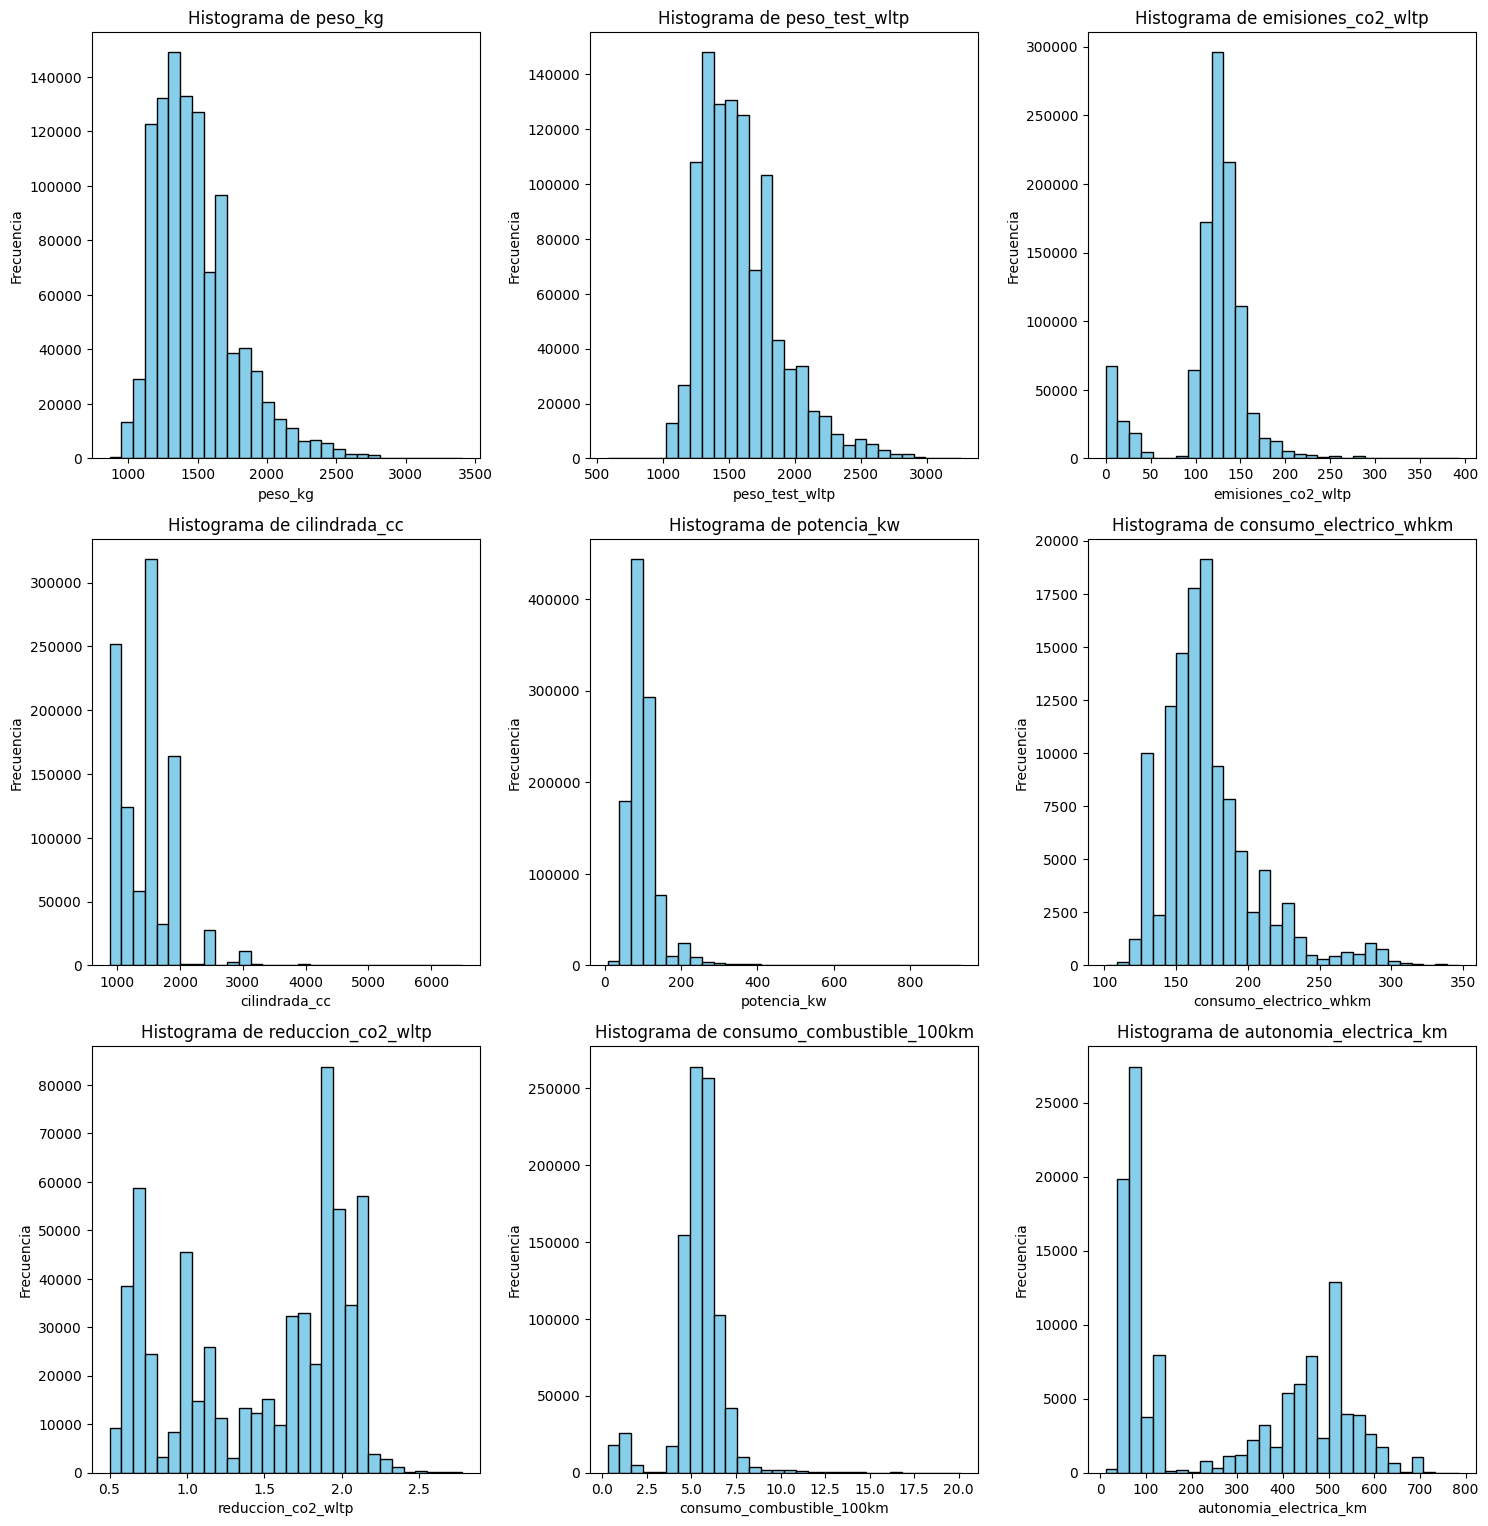

In [7]:
# Identificar las columnas numéricas
import numpy as np
import matplotlib.pyplot as plt

numeric_columns = data.select_dtypes(include=[np.number]).columns
print("Variables numéricas: ", numeric_columns.values)

# Crear una figura con subplots
num_vars = len(numeric_columns)
fig, axes = plt.subplots(nrows=(num_vars // 3) + 1, ncols=3, figsize=(15, 5 * ((num_vars // 3) + 1)))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    # Graficar el histograma
    axes[i].hist(data[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar ejes sobrantes si hay menos de 3 variables
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

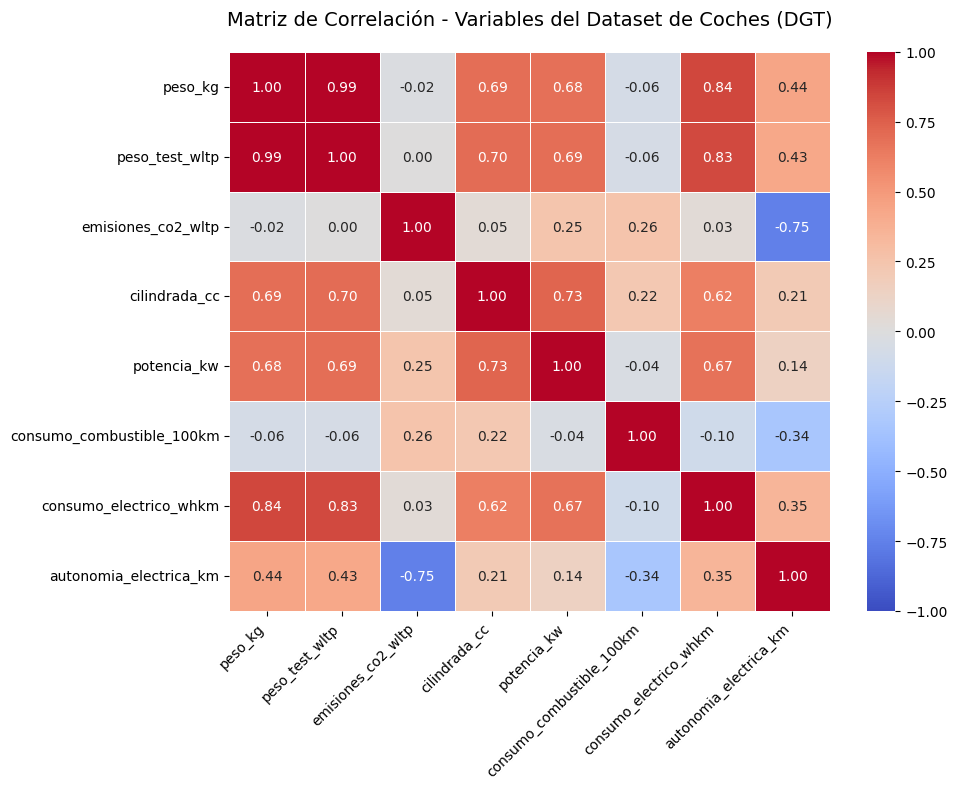

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionamos las variables numéricas reales y sin muchos nulos
num_vars_coches = [
    'peso_kg', 
    'peso_test_wltp',
    'emisiones_co2_wltp', 
    'cilindrada_cc', 
    'potencia_kw', 
    'consumo_combustible_100km', 
    'consumo_electrico_whkm', 
    'autonomia_electrica_km'
]

data_num = data[num_vars_coches].dropna()

# MATRIZ DE CORRELACIÓN (Numérica)
plt.figure(figsize=(10, 8)) 
correlacion = data_num.corr() 
sns.heatmap(
    correlacion, 
    annot=True,          # Muestra los números dentro de los cuadrados
    cmap='coolwarm',     # Azul para correlación negativa, rojo para positiva
    fmt=".2f",           # Redondea a dos decimales
    linewidths=0.5,      # Separa los cuadrados con una línea fina
    vmin=-1,             # Escala mínima del coeficiente
    vmax=1               # Escala máxima del coeficiente
)

plt.title('Matriz de Correlación - Variables del Dataset de Coches (DGT)', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right') # Rota los nombres del eje X para que no se solapen
plt.tight_layout() 
plt.show()

Hay una multicorrelación entre las dos primeras variables, con la que nos tendríamos que eliminado (***peso_test_wltp por criterios***) por redundancia lineal. Podemor ver valores muy correlacionadas como (***peso_kg***) y (***consumo_electrico_whkm***) con 0.84 y (***emisiones_co2_wltp***) con (***autonomia_electrica_km***) con -0.75.

Ahora vamos a pintar gráficamente estas relaciones para ver como efectivamente están altamente correladas.

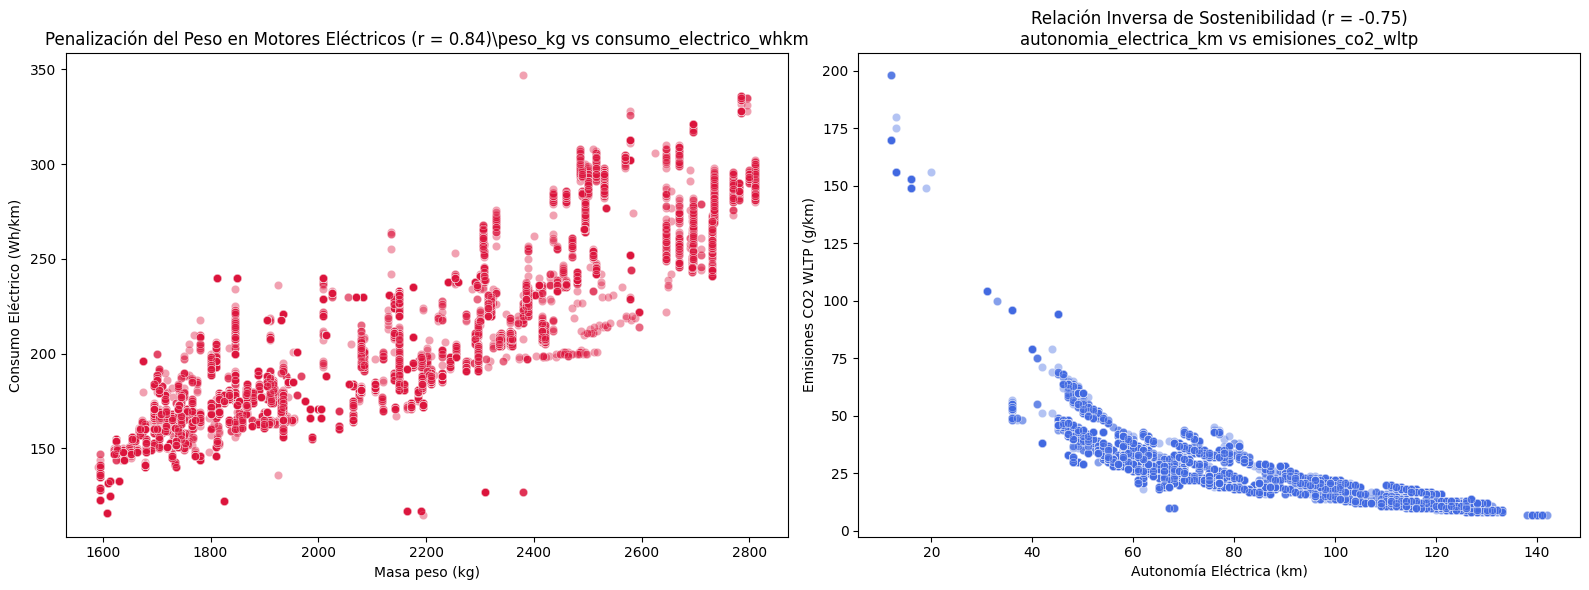

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el espacio para dos gráficos avanzados cruzando variables distintas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Impacto del Peso en el Consumo Eléctrico (Relación Directa)
sns.scatterplot(data=data_num, x='peso_kg', y='consumo_electrico_whkm', alpha=0.4, ax=axes[0], color='crimson')
axes[0].set_title('Penalización del Peso en Motores Eléctricos (r = 0.84)\peso_kg vs consumo_electrico_whkm', fontsize=12)
axes[0].set_xlabel('Masa peso (kg)')
axes[0].set_ylabel('Consumo Eléctrico (Wh/km)')

# Gráfico 2: Autonomía vs Emisiones CO2 (Relación Inversa Clave DGT)
sns.scatterplot(data=data_num, x='autonomia_electrica_km', y='emisiones_co2_wltp', alpha=0.4, ax=axes[1], color='royalblue')
axes[1].set_title('Relación Inversa de Sostenibilidad (r = -0.75)\nautonomia_electrica_km vs emisiones_co2_wltp', fontsize=12)
axes[1].set_xlabel('Autonomía Eléctrica (km)')
axes[1].set_ylabel('Emisiones CO2 WLTP (g/km)')

plt.tight_layout()
plt.show()

## Análisis de Variables Categóricas

In [10]:
# Identificar las variables categóricas
category_columns = data.select_dtypes(include=['object', 'category', 'str']).columns
print("Variables categóricas: ", category_columns.values)

# Calcular la cardinalidad de cada columna
cardinalities = data[category_columns].nunique()
print('\n',cardinalities.sort_values(ascending=False))

Variables categóricas:  <ArrowStringArray>
[ 'id_familia_vehiculo',     'pool_fabricantes',        'fabricante_ue',
       'fabricante_oem',     'num_homologacion',                 'tipo',
             'variante',              'version',                'marca',
     'modelo_comercial', 'categoria_homologada', 'categoria_registrada',
     'tipo_combustible',      'modo_propulsion', 'codigo_ecoinnovacion',
          'estado_dato',  'fecha_matriculacion',                  'ech',
                 'RLFI']
Length: 19, dtype: str

 version                 7067
id_familia_vehiculo     2631
variante                2039
modelo_comercial        1899
num_homologacion        1789
RLFI                     520
tipo                     455
fecha_matriculacion      253
fabricante_ue             77
marca                     75
fabricante_oem            75
codigo_ecoinnovacion      55
ech                       12
pool_fabricantes          11
tipo_combustible           8
modo_propulsion            5
categ

In [11]:
# Identificar las variables categóricas
print("Variables categóricas: ", category_columns.values)

for column in category_columns:
    print(f"\nFrecuencia de la columna {column}:")
    print(data[column].value_counts())

Variables categóricas:  <ArrowStringArray>
[ 'id_familia_vehiculo',     'pool_fabricantes',        'fabricante_ue',
       'fabricante_oem',     'num_homologacion',                 'tipo',
             'variante',              'version',                'marca',
     'modelo_comercial', 'categoria_homologada', 'categoria_registrada',
     'tipo_combustible',      'modo_propulsion', 'codigo_ecoinnovacion',
          'estado_dato',  'fecha_matriculacion',                  'ech',
                 'RLFI']
Length: 19, dtype: str

Frecuencia de la columna id_familia_vehiculo:
id_familia_vehiculo
IP-HNE____MB6D542C-VR3    20414
IP-ZS11_2020_02-LSJ-1     11930
IP-0211-JT1               11254
IP-0200-JT1-1             10956
IP-03_312_0344-ZFA-1      10636
                          ...  
762                           1
IP-2019_2423-WDB-1            1
IP-MQB37AS_B0_119             1
IP-0502601-KMH-1              1
IP-0000923-WBA-1              1
Name: count, Length: 2631, dtype: int64

Frecuencia 

Hay unas posibles variables que se pueden reducir

In [12]:
pd.set_option('display.max_rows', None)

category = [ 'marca', 'fabricante_oem', 'fabricante_ue', 'ech', 'pool_fabricantes', 'tipo_combustible', 'modo_propulsion'  ]
print("Variables categóricas: ", category)

for column in category:
    print(f"\nFrecuencia de la columna {column}:")
    print(data[column].value_counts())

Variables categóricas:  ['marca', 'fabricante_oem', 'fabricante_ue', 'ech', 'pool_fabricantes', 'tipo_combustible', 'modo_propulsion']

Frecuencia de la columna marca:
marca
TOYOTA                           100873
VOLKSWAGEN                        76002
RENAULT                           71362
SEAT                              65287
HYUNDAI                           64844
KIA                               59901
PEUGEOT                           56907
DACIA                             54755
MERCEDES-BENZ                     49487
BMW                               44654
CITROEN                           43199
AUDI                              38786
SKODA                             38250
NISSAN                            32631
MG                                30774
FORD                              30253
OPEL                              27043
CUPRA                             22168
VOLVO                             18175
MAZDA                             17523
TESLA                     

Al contrastar las columnas `marca`, `fabricante_oem` y `fabricante_ue`, se determina **conservar únicamente la variable `marca`** y descartar las otras dos por la calidad del dato. 
La idea es crear las siguientes variables:
* **`marca` (De 75 a 6 categorías):** Se agrupan los fabricantes por sinergias corporativas y posicionamiento de mercado (`GRUPO_VW`, `GRUPO_STELLANTIS_RENAULT`, `ASIATICAS_VOLUMEN`, `PREMIUM_EUROPA`, `ELECTRICAS_NATIVAS` y un saco común de `OTRAS_MARCAS` para firmas minoritarias).
* **`tipo_combustible` (De 8 a 4 categorías):** Se unifican tecnologías afines bajo los criterios reales de los cortes de la DGT (`GASOLINA` [incluye GLP/Gas], `DIESEL`, `HIBRIDO` y `ELECTRICO` [incluye Hidrógeno]).
* **`ech` / Normativa EURO (De 12 a 3 categorías):** Se simplifica la sopa de letras técnica de la normativa Euro 6 según la severidad del año de homologación del motor (`EURO_6_STANDARD`, `EURO_6_AVANZADA` y `EURO_PESADOS`).

Nos quedamos con las nuevas variables y `modo_propulsion`, las demas se expluyen por tener una alta cardinalidad o tener una categoría única,

### 1.3 Preparación de los datos

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1055935 entries, 0 to 1055934
Data columns (total 28 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   id_familia_vehiculo        976263 non-null   str    
 1   pool_fabricantes           983485 non-null   str    
 2   fabricante_ue              1055935 non-null  str    
 3   fabricante_oem             1055935 non-null  str    
 4   num_homologacion           1055935 non-null  str    
 5   tipo                       1055933 non-null  str    
 6   variante                   1055904 non-null  str    
 7   version                    1055693 non-null  str    
 8   marca                      1055935 non-null  str    
 9   modelo_comercial           1055932 non-null  str    
 10  categoria_homologada       1055935 non-null  str    
 11  categoria_registrada       1055935 non-null  str    
 12  peso_kg                    1055934 non-null  float64
 13  peso_test_wltp         

In [14]:
def preparacion(data_raw):

    data = data_raw.copy()
    data.columns = data.columns.str.strip()

    # 1. Agrupación de MARCAS
    def agrupar_marcas(marca):
        grupo_vw = ['VOLKSWAGEN', 'SEAT', 'AUDI', 'SKODA', 'CUPRA', 'PORSCHE']
        grupo_stellantis_francia = ['RENAULT', 'PEUGEOT', 'CITROEN', 'DACIA', 'OPEL', 'FIAT', 'DS', 'ALFA ROMEO']
        asiaticas_volumen = ['TOYOTA', 'HYUNDAI', 'KIA', 'NISSAN', 'MG', 'MAZDA', 'LEXUS', 'SUZUKI', 'HONDA', 'MITSUBISHI']
        premium = ['MERCEDES-BENZ', 'BMW', 'VOLVO', 'MINI', 'LAND ROVER', 'JAGUAR']
        electricas_puras = ['TESLA', 'BYD', 'POLESTAR', 'SMART']
        
        if marca in grupo_vw: return 'GRUPO_VW'
        elif marca in grupo_stellantis_francia: return 'GRUPO_STELLANTIS_RENAULT'
        elif marca in asiaticas_volumen: return 'ASIATICAS_VOLUMEN'
        elif marca in premium: return 'PREMIUM_EUROPA'
        elif marca in electricas_puras: return 'ELECTRICAS_NATIVAS'
        else: return 'OTRAS_MARCAS'

    data['marca_agrupada'] = data['marca'].apply(agrupar_marcas)
    
    # 2. Agrupación de COMBUSTIBLES
    dicc_combustibles = {
        'petrol': 'GASOLINA', 'lpg': 'GASOLINA', 'ng': 'GASOLINA',
        'diesel': 'DIESEL',
        'petrol/electric': 'HIBRIDO', 'diesel/electric': 'HIBRIDO',
        'electric': 'ELECTRICO', 'hydrogen': 'ELECTRICO'
    }
    data['combustible_agrupado'] = data['tipo_combustible'].map(dicc_combustibles)

     # --- Verificación de cobertura del mapeo ---
    valores_sin_mapear = data.loc[data['combustible_agrupado'].isna(), 'tipo_combustible'].unique()
    n_nulos = data['combustible_agrupado'].isna().sum()
    if n_nulos > 0:
        print(f"⚠️ {n_nulos} filas ({n_nulos/len(data):.2%}) sin mapear en 'tipo_combustible'.")
        print(f"   Valores no contemplados en el diccionario: {valores_sin_mapear}")
    else:
        print("✅ 'combustible_agrupado': mapeo completo, 0 nulos generados.")
    
    # 3. Agrupación de la variable ECH (Normativa EURO 6)
    dicc_euro = {
        'EURO 6 EA': 'EURO_6_STANDARD', 'EURO 6 EC': 'EURO_6_STANDARD', 
        'EURO 6 EB': 'EURO_6_STANDARD', 'EURO 6': 'EURO_6_STANDARD',
        'EURO 6 AZ': 'EURO_6_STANDARD', 'EURO 6 AR': 'EURO_6_STANDARD',
        'EURO 6 AP': 'EURO_6_AVANZADA', 'EURO 6 E': 'EURO_6_AVANZADA',
        'EURO AX': 'EURO_PESADOS', 'EURO VI E': 'EURO_PESADOS', 
        'EURO VI': 'EURO_PESADOS', 'EURO AY': 'EURO_PESADOS'
    }
    data['normativa_euro'] = data['ech'].map(dicc_euro)

      # --- Verificación de cobertura del mapeo ---
    valores_sin_mapear_euro = data.loc[data['normativa_euro'].isna(), 'ech'].unique()
    n_nulos_euro = data['normativa_euro'].isna().sum()
    if n_nulos_euro > 0:
        print(f"⚠️ {n_nulos_euro} filas ({n_nulos_euro/len(data):.2%}) sin mapear en 'ech'.")
        print(f"   Valores no contemplados en el diccionario: {valores_sin_mapear_euro}")
    else:
        print("✅ 'normativa_euro': mapeo completo, 0 nulos generados.")

    # 4. ELIMINACIÓN DE VARIABLES (Comas añadidas y 'modo_propulsion' salvado para dummificar)
    var_eliminar = [ 
        'id_familia_vehiculo', 'modelo_comercial', 'num_homologacion', 'RLFI',
        'pool_fabricantes', 'fabricante_ue', 'fabricante_oem', 'tipo', 'variante', 'version', 
        'fecha_matriculacion', 'codigo_ecoinnovacion', 'categoria_homologada', 
        'categoria_registrada', 'estado_dato', 'peso_test_wltp', 'reduccion_co2_wltp',
        'marca', 'tipo_combustible', 'ech' 
    ]

    data.drop(columns=var_eliminar, errors='ignore', inplace=True)

    # 5. IMPUTACIÓN DE NULOS
    # Incompatibilidad lógica (0.0)
    data['consumo_electrico_whkm'] = data['consumo_electrico_whkm'].fillna(0.0)
    data['autonomia_electrica_km'] = data['autonomia_electrica_km'].fillna(0.0)
    data['consumo_combustible_100km'] = data['consumo_combustible_100km'].fillna(0.0)
    data['cilindrada_cc'] = data['cilindrada_cc'].fillna(0.0)
    
    # Estabilización estadística (Mediana)
    data['emisiones_co2_wltp'] = data['emisiones_co2_wltp'].fillna(data['emisiones_co2_wltp'].median())
    data['peso_kg'] = data['peso_kg'].fillna(data['peso_kg'].median())
    data['potencia_kw'] = data['potencia_kw'].fillna(data['potencia_kw'].median())

    # 6. ONE-HOT ENCODING 
    vars_to_dummy = ['marca_agrupada', 'combustible_agrupado', 'modo_propulsion', 'normativa_euro']
    data = pd.get_dummies(data, columns=vars_to_dummy, dtype=int)

    return data

In [15]:
data = preparacion(data)
data.info()

✅ 'combustible_agrupado': mapeo completo, 0 nulos generados.
✅ 'normativa_euro': mapeo completo, 0 nulos generados.
<class 'pandas.DataFrame'>
RangeIndex: 1055935 entries, 0 to 1055934
Data columns (total 25 columns):
 #   Column                                   Non-Null Count    Dtype  
---  ------                                   --------------    -----  
 0   peso_kg                                  1055935 non-null  float64
 1   emisiones_co2_wltp                       1055935 non-null  float64
 2   cilindrada_cc                            1055935 non-null  float64
 3   potencia_kw                              1055935 non-null  float64
 4   consumo_electrico_whkm                   1055935 non-null  float64
 5   consumo_combustible_100km                1055935 non-null  float64
 6   autonomia_electrica_km                   1055935 non-null  float64
 7   marca_agrupada_ASIATICAS_VOLUMEN         1055935 non-null  int64  
 8   marca_agrupada_ELECTRICAS_NATIVAS        1055935 non-null

## 2. Segundo paso PCA: Estandarizar los datos y verificar relaciones entre variables

A continuación, se procede a la estandarización de las variables cuantitativas continuas mediante el cálculo de puntuaciones Z (Z-score). Excluyendo las que han sido previamente codificadas mediante One-Hot Encoding, garantizando así que no se altere su naturaleza binaria (0 y 1)

### estandalización

In [16]:
var_continuas = [
    'peso_kg', 'emisiones_co2_wltp', 'cilindrada_cc', 'potencia_kw', 
    'consumo_electrico_whkm', 'consumo_combustible_100km', 'autonomia_electrica_km'
]

data_sin_escalar = data.copy()

# estandarizamos las variables numericas
data[var_continuas] = (data[var_continuas] -data[var_continuas].mean()) / data[var_continuas].std()

# Verificación rápida: media ≈ 0, desviación ≈ 1
print(data[var_continuas].mean().round(3))
print(data[var_continuas].std().round(3))

peso_kg                      0.0
emisiones_co2_wltp           0.0
cilindrada_cc               -0.0
potencia_kw                  0.0
consumo_electrico_whkm      -0.0
consumo_combustible_100km    0.0
autonomia_electrica_km      -0.0
dtype: float64
peso_kg                      1.0
emisiones_co2_wltp           1.0
cilindrada_cc                1.0
potencia_kw                  1.0
consumo_electrico_whkm       1.0
consumo_combustible_100km    1.0
autonomia_electrica_km       1.0
dtype: float64


### Matrices de correlación y covarianza

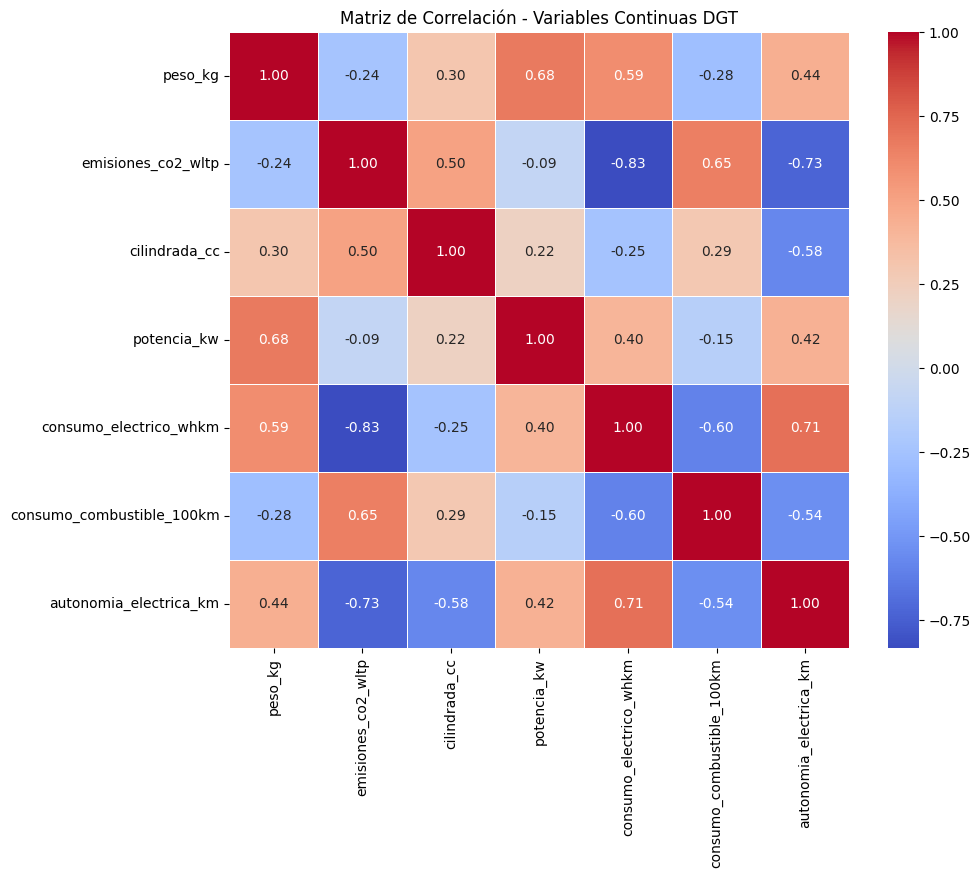

In [17]:

# Calculamos la matriz de correlación 
matriz_corr = data[var_continuas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Variables Continuas DGT')
plt.show()

### Prueba KMO (Kaiser-Meyer-Olkin)

In [18]:
! pip install factor_analyzer

In [19]:
from factor_analyzer import calculate_kmo

# Calcular el índice KMO
kmo_all, kmo_model = calculate_kmo(data[var_continuas])

# Mostrar el índice KMO general
print(f"Índice KMO (global): {kmo_model:.4f}")

# Mostrar el índice KMO por variable
print("Índices KMO por variable:")
print(kmo_all)
print(data[var_continuas].columns)

Índice KMO (global): 0.6316
Índices KMO por variable:
[0.54959222 0.63281217 0.45627622 0.60424357 0.68277937 0.94741467
 0.62286987]
Index(['peso_kg', 'emisiones_co2_wltp', 'cilindrada_cc', 'potencia_kw',
       'consumo_electrico_whkm', 'consumo_combustible_100km',
       'autonomia_electrica_km'],
      dtype='str')


El resultado muestra un coeficiente de 0.63 que podríamos decir que está entre regular y aceptable. Por debajo de 0.6 sería demasiado pobre como para que merezca la pena. De entre las variables las que tira habia abajo el índice es **cilindrada_cc**, vamos a volver a probar el KMO sin esta variable..

In [23]:
var_continuas = [
    'peso_kg', 'emisiones_co2_wltp', 'potencia_kw', 
    'consumo_electrico_whkm', 'consumo_combustible_100km', 'autonomia_electrica_km'
]
# estandarizamos las variables numericas
data[var_continuas] = (data[var_continuas] -data[var_continuas].mean()) / data[var_continuas].std()

# Calcular el índice KMO
kmo_all, kmo_model = calculate_kmo(data[var_continuas])

# Mostrar el índice KMO general
print(f"Índice KMO (global): {kmo_model:.4f}")

# Mostrar el índice KMO por variable
print("Índices KMO por variable:")
print(kmo_all)
print(data[var_continuas].columns)

Índice KMO (global): 0.7001
Índices KMO por variable:
[0.65083452 0.59347127 0.63677945 0.68441826 0.94083972 0.80441998]
Index(['peso_kg', 'emisiones_co2_wltp', 'potencia_kw',
       'consumo_electrico_whkm', 'consumo_combustible_100km',
       'autonomia_electrica_km'],
      dtype='str')


### Prueba de Bartlett

In [24]:
from factor_analyzer import calculate_bartlett_sphericity

# Realizar el test de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(data[var_continuas])

# Mostrar resultados
print(f"Valor de chi-cuadrado: {chi_square_value:.4f}")
print(f"p-valor: {p_value:.4f}")

Valor de chi-cuadrado: 4584593.2652
p-valor: 0.0000


El p-valor de la prueba de esfericidad de Bartlett se sitúa en $0.0000$, un valor estrictamente por debajo del umbral crítico de $0.05$. Este resultado, respaldado por un Índice KMO global de $0.7$ que se mantiene en niveles aceptables para el conjunto total de las 6 variables mecánicas (eliminando `cilindrada_cc`), confirma de manera empírica que la matriz de datos presenta una estructura de correlación interna altamente significativa.

En resumen, la matriz de correlación, el test de Kaiser-Meyer-Olkin y la esfericidad de Bartlett— determinan de forma unánime que el dataset de la DGT es un candidato idóneo para un Análisis de Componentes Principales (PCA), sin necesidad de prescindir de ningún atributo técnico relevante.

Por lo tanto, queda completamente validado el paso a la fase de modelado, donde procederemos a instanciar y ajustar el algoritmo de reducción dimensional con nuestra matriz de datos estandarizada.

In [25]:
from sklearn.decomposition import PCA
# Crear un modelo de componentes principales ajustado a los datos númericos
pca = PCA()
pca.fit(data[var_continuas])

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

Para realizar el analisis lo primero que es calcular los autovectores y autovalores. Los recogemos y los almacenamos en variables para utilizarlos después. También le pedimos al modelo que nos devuelva los autovalores en porcentaje respecto de todos ellos.

In [26]:
# Recuperamos la información de autovalores y autovectores
explained_var = pca.explained_variance_
explained_var_ratio = pca.explained_variance_ratio_
autovectores = pca.components_

### Varianza explicada y acumulada

In [27]:
df_pca_results = pd.DataFrame({
    'Componente': np.arange(1, pca.n_components_ + 1),
    'Explained Variance': explained_var,
    'Explained Variance Ratio': explained_var_ratio,
    'Cumulative Variance Ratio': np.cumsum(explained_var_ratio)
})

df_pca_results

,Componente,Explained Variance,Explained Variance Ratio,Cumulative Variance Ratio
0,1,3.527156,0.587859,0.587859
1,2,1.330707,0.221784,0.809644
2,3,0.460706,0.076784,0.886428
3,4,0.388267,0.064711,0.951139
4,5,0.223952,0.037325,0.988465
5,6,0.069212,0.011535,1.000000


Este dataframe nos muestra cada componente que el modelo nos ha generado. Cada una tiene un autovalor asociado que sería la varianza explicada de los datos sobre ducha componente, y también se muestra el porcentaje que supone cada una sobre el total de varianza explicada por todas estas componentes. Por último se muestra, al tener ordenados de mayor a menor varianza explicada, la suma acumulada de los porcentajes.

Con los 2 componentes ya explicamos el 80% de la varianza, quedándonos con los componentes 1 y 2. 

Vamos a mostrar esta información gráficamente:

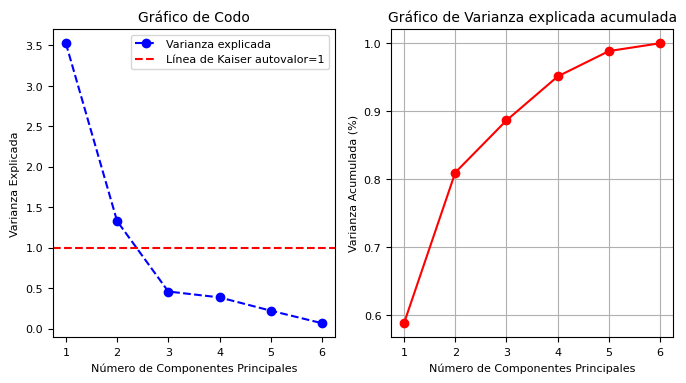

In [28]:
plt.figure(figsize=(8, 4))

# Varianza explicada por cada componente
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o', linestyle='--', color='b', label='Varianza explicada')
plt.axhline(y=1, color='r', linestyle='--', label='Línea de Kaiser autovalor=1')
plt.title('Gráfico de Codo', fontsize=10)
plt.xlabel('Número de Componentes Principales', fontsize=8)
plt.ylabel('Varianza Explicada', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend(fontsize=8)

# Varianza explicada acumulada
plt.subplot(1, 2, 2)
cumulative_var_ratio = np.cumsum(explained_var_ratio)
plt.plot(range(1, len(cumulative_var_ratio) + 1), cumulative_var_ratio, marker='o', linestyle='-', color='r', label='Varianza explicada acumulada')
plt.title('Gráfico de Varianza explicada acumulada', fontsize=10)
plt.xlabel('Número de Componentes Principales', fontsize=8)
plt.ylabel('Varianza Acumulada (%)', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Mostrar el gráfico
plt.grid(True)
plt.show()

Viendo los dos criterios podemos ver:

- Criterio de varianza acumulada (80%): PC1+PC2 = 80.9% 
- Criterio de Kaiser (autovalor > 1): la línea de referencia (autovalor = 1) cae entre PC2 y PC3, es decir, PC1 y PC2 tienen autovalor > 1 (aportan más información que una variable original), y a partir de PC3 los autovalores ya caen por debajo de ese umbral
- En el gráfico de varianza, un valor habitual suele ser 80% por lo que en nuestros datos, si cogemos 2 componentes tenemos un 80% y si cogemos 3 tenemos un 88%. En nuestro caso vamos a quedarnos con 2 componentes de forma que alcanzamos el 80% de la varianza conjunta explicada y reduce mucho la dimensionalidad de los datos.

El siguiente paso es calcular la matriz que nos permitirá proyectar los datos a las componentes elegidas. Esta matriz se calcula como la matríz formada por los autovectores escogidos multiplicado por la raíz cuadrada de la matriz diagonal de autovalores. Los valores de la matriz resultante son los coeficientes de saturación o cargas.

In [36]:
# Construimos matriz de autovectores seleccionados
V12 = pd.DataFrame((autovectores[0], autovectores[1])) .T

# Proyección de variables sobre los 2 componentes (matriz L)
proyected_matrix = V12 * (explained_var[:2]**0.5)
proyected_matrix.set_index(pd.Index(var_continuas), inplace=True)
proyected_matrix.columns = ['Comp_1', 'Comp_2']

# Mostrar tabla
proyected_matrix

,Comp_1,Comp_2
peso_kg,0.668764,0.612292
emisiones_co2_wltp,-0.820231,0.484220
potencia_kw,0.539735,0.752539
consumo_electrico_whkm,0.926046,-0.080564
consumo_combustible_100km,-0.722225,0.376090
autonomia_electrica_km,0.858281,-0.084182


Se puede ver que en el **componente 1** tiene mucho peso las variables relacionadas con la **emisión y consumo** del coche, y en el **componente 2** tiene más peso la **potencía y kg** del coche

### Círculo de correlaciones (interpretar qué representa cada componente)

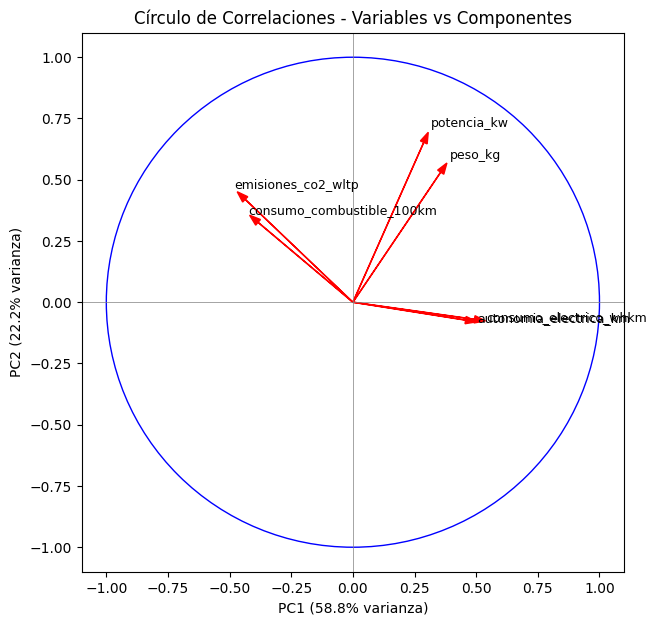

In [32]:
#Matriz de autovectores de las 2 primeras componentes
V12 = pd.DataFrame((autovectores[0], autovectores[1])).T
V12.index = var_continuas
V12.columns = ['PC1', 'PC2']

fig, ax = plt.subplots(figsize=(7, 7))

# Círculo de radio 1
circle = plt.Circle((0, 0), 1, color='blue', fill=False)
ax.add_artist(circle)

# Flechas para cada variable
for i, var in enumerate(var_continuas):
    ax.arrow(0, 0, V12.iloc[i, 0], V12.iloc[i, 1], head_width=0.03, color='red')
    ax.text(V12.iloc[i, 0]*1.1, V12.iloc[i, 1]*1.1, var, fontsize=9)

ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(f'PC1 ({explained_var_ratio[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({explained_var_ratio[1]:.1%} varianza)')
ax.set_title('Círculo de Correlaciones - Variables vs Componentes')
plt.show()